# 02 — Plots
Loads processed results from `data/processed/model_outputs.pkl` and produces all figures.
**Run `01_model.ipynb` first.**

## Imports + load data

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.interpolate import interp1d

data_folder = Path.cwd().parent / 'data' / 'processed'

# Load CSVs
stock_df      = pd.read_csv(data_folder / 'stock_df.csv')
results       = pd.read_csv(data_folder / 'results.csv')
future        = pd.read_csv(data_folder / 'future.csv')
steel_stock_pop = pd.read_csv(data_folder / 'steel_stock_pop.csv')

# Load pickle
with open(data_folder / 'model_outputs.pkl', 'rb') as f:
    d = pickle.load(f)

scenarios_primary    = d['scenarios_primary']
years                = d['years']
plot_years           = d['plot_years']
production_results   = d['production_results']
emissions_results    = d['emissions_results']
emissions_factor_BF  = d['emissions_factor_BF']
emissions_factor_EAF = d['emissions_factor_EAF']
electrode_rate       = d['electrode_rate']
MW_CO2               = d['MW_CO2']
MW_C                 = d['MW_C']
h2_results           = d['h2_results']
electrolyzer_shares  = d['electrolyzer_shares']
aec_share            = d['aec_share']
pem_share            = d['pem_share']
other_share          = d['other_share']
cap_results          = d['cap_results']
dsm_results          = d['dsm_results']
materials            = d['materials']
nickel_intensity     = d['nickel_intensity']
platinum_intensity   = d['platinum_intensity']
iridium_intensity    = d['iridium_intensity']
efficiency_AEC       = d['efficiency_AEC']
efficiency_PEM       = d['efficiency_PEM']
available_hours_AEC  = d['available_hours_AEC']
available_hours_PEM  = d['available_hours_PEM']
s_vehicles           = d['s_vehicles']
s_machinery          = d['s_machinery']
s_bc                 = d['s_bc']
s_appliances         = d['s_appliances']
lt_vehicles          = d['lt_vehicles']
lt_machinery         = d['lt_machinery']
lt_bc                = d['lt_bc']
lt_appliances        = d['lt_appliances']
k_fit                = d['k_fit']
x0_fit               = d['x0_fit']
wsa_production       = d['wsa_production']

wsa_years  = list(wsa_production.keys())
wsa_values = [v * 1e6 for v in wsa_production.values()]

xlims = (years[0], years[-1])
print('Data loaded.')

Data loaded.


## 1. Total in-use steel stock

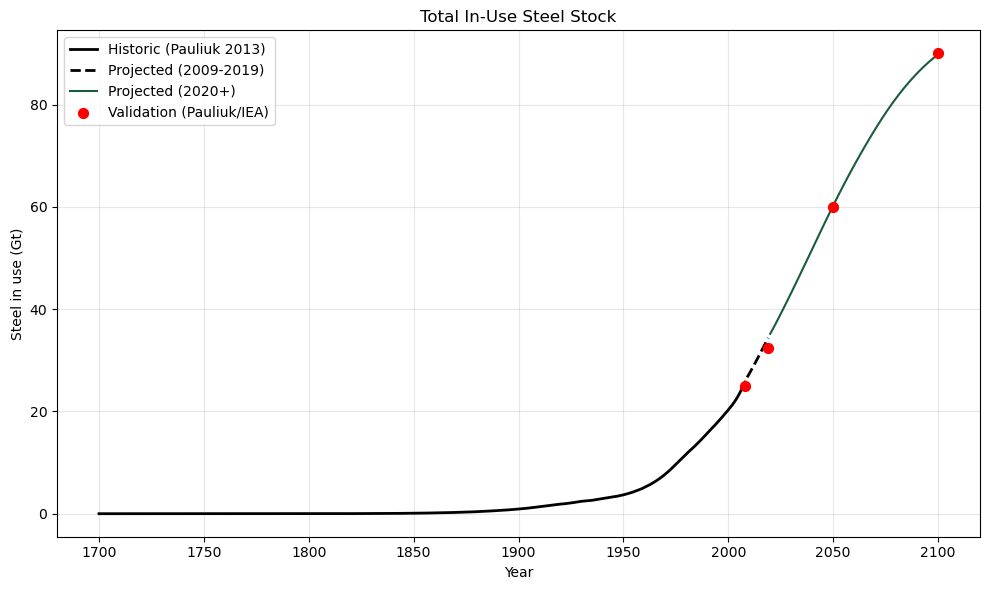

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

hist   = stock_df[stock_df['type'] == 'historic']
recent = stock_df[stock_df['type'] == 'recent']
pred   = stock_df[stock_df['type'] == 'predicted']

ax.plot(hist['year'],   hist['total_stock']   / 1e9, color='black',   linewidth=2,   label='Historic (Pauliuk 2013)')
ax.plot(recent['year'], recent['total_stock'] / 1e9, color='black',   linewidth=2,   linestyle='--', label='Projected (2009-2019)')
ax.plot(pred['year'],   pred['total_stock']   / 1e9, color='#1a5c3a', linewidth=1.5, label='Projected (2020+)')

# Validation points
ax.scatter([2008, 2019, 2050, 2100], [25, 32.3, 60, 90],
           color='red', zorder=5, s=50, label='Validation (Pauliuk/IEA)')

ax.set_xlabel('Year')
ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Inflow, outflow and stock change by sector

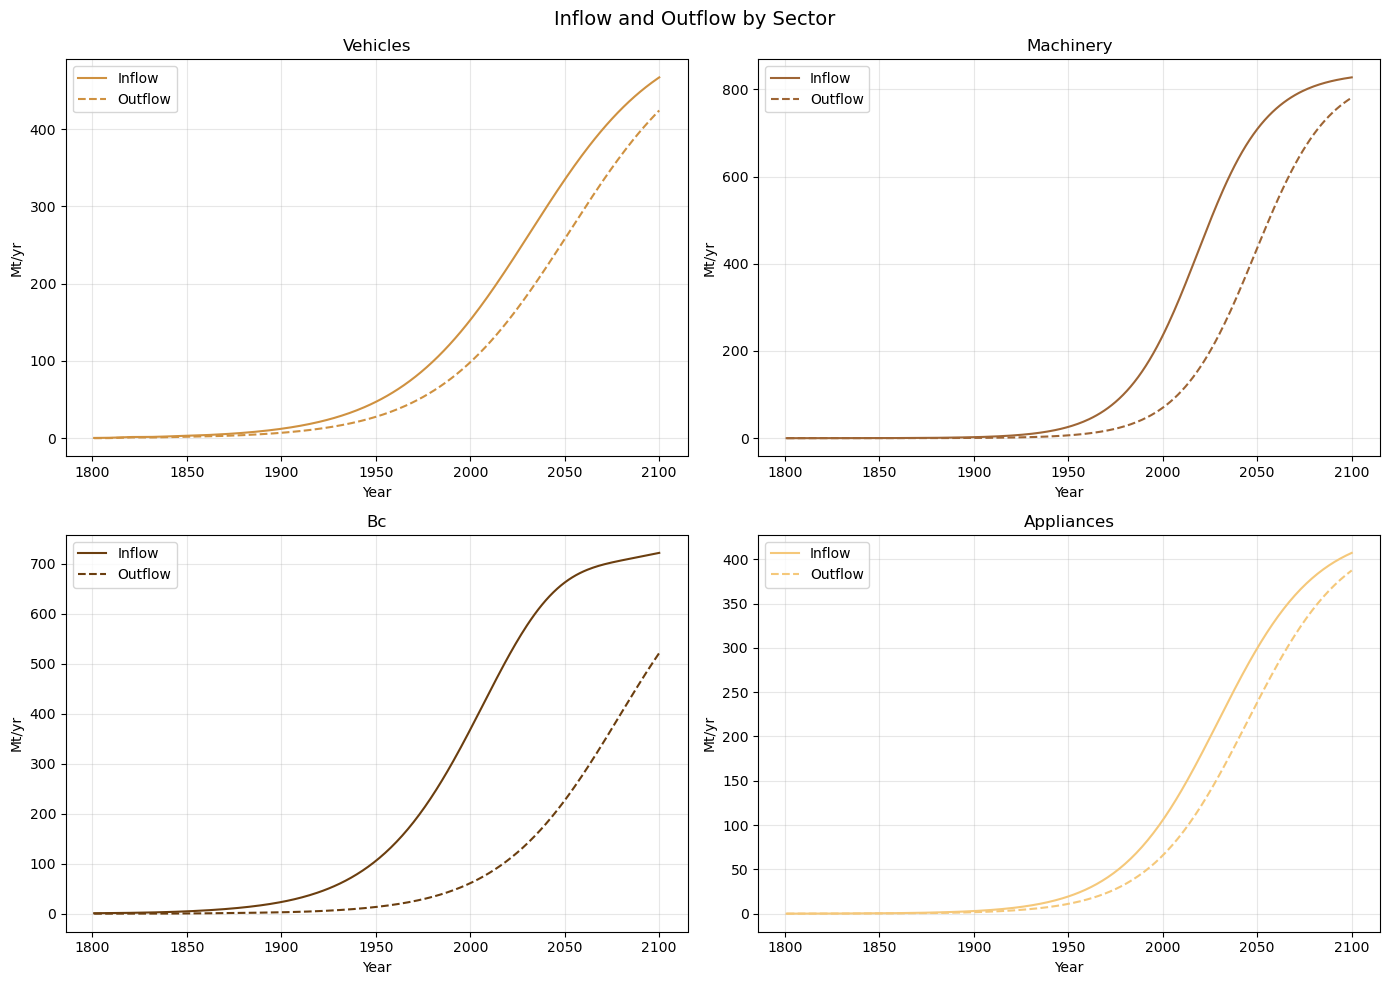

In [4]:
colors = ['#cf9140', '#9e6535', '#6b3e0f', '#f5c87a']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Inflow and Outflow by Sector', fontsize=14)

for ax, cat, color in zip(axes.flat,
    ['vehicles', 'machinery', 'BC', 'appliances'], colors):
    col_i = f'inflow_{cat}'
    col_o = f'outflow_{cat}'
    ax.plot(results['Year'], results[col_i] / 1e6, label='Inflow',  color=color, linestyle='-')
    ax.plot(results['Year'], results[col_o] / 1e6, label='Outflow', color=color, linestyle='--')
    ax.set_title(cat.replace('_', ' & ').title())
    ax.set_xlabel('Year'); ax.set_ylabel('Mt/yr')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Total crude steel needed vs WSA production

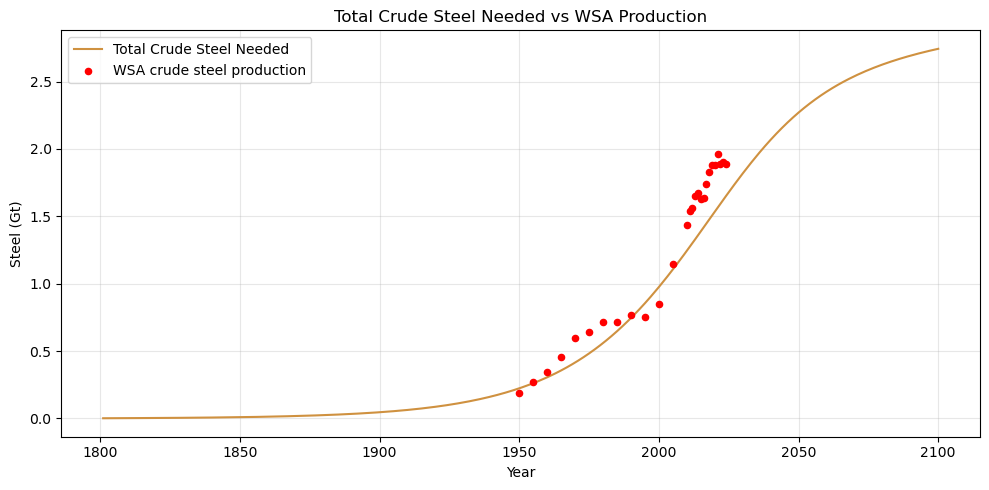

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['Year'], results['total_steel_needed'] / 1e9, label='Total Crude Steel Needed', color='#cf9140')
ax.scatter(wsa_years, [v / 1e9 for v in wsa_values], color='red', s=20, zorder=5, label='WSA crude steel production')
ax.set_xlabel('Year'); ax.set_ylabel('Steel (Gt)')
ax.set_title('Total Crude Steel Needed vs WSA Production')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Steel supply transition (H-DRI wedge) — first scenario only

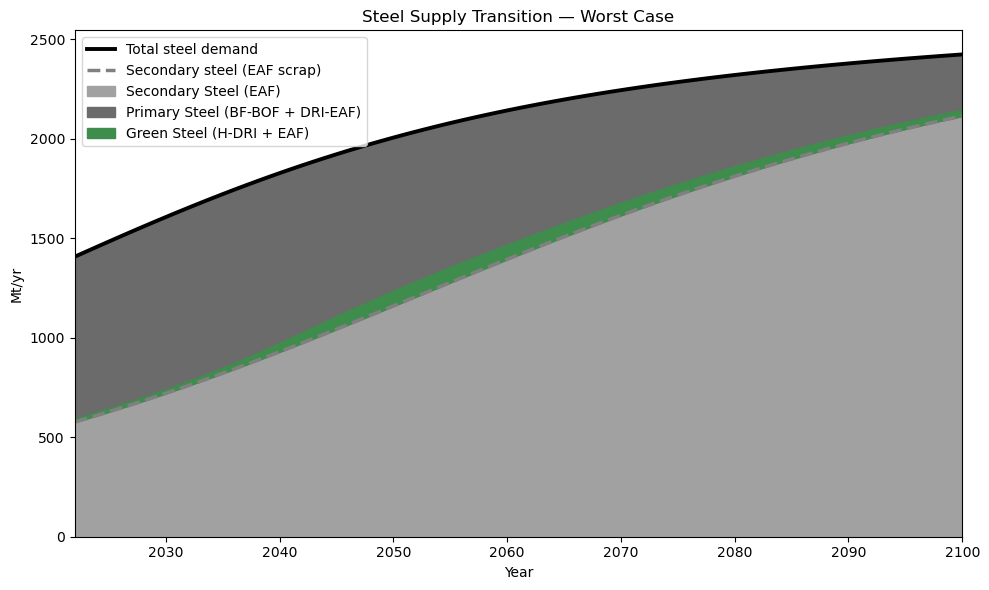

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
scenario = list(scenarios_primary.keys())[0]

eaf  = future['scrap_supply'].values / 1e6
bf   = production_results[scenario]['BF Production']  / 1e6
dri  = production_results[scenario]['DRI Production'] / 1e6
total_demand = future['total_inflow'].values / 1e6

ax.plot(plot_years, total_demand, color='black', linewidth=2.8, label='Total steel demand')
ax.plot(plot_years, eaf,          color='gray',  linewidth=2.5, linestyle='--', label='Secondary steel (EAF scrap)')
ax.fill_between(plot_years, 0,   eaf,         color='#A1A1A1', alpha=1.0, label='Secondary Steel (EAF)')
ax.fill_between(plot_years, eaf, eaf+dri+bf,  color='#6b6b6b', alpha=1.0, label='Primary Steel (BF-BOF + DRI-EAF)')
ax.fill_between(plot_years, eaf, eaf+dri,     color='#3f8d4c', alpha=1.0, label='Green Steel (H-DRI + EAF)')
ax.set_title(f'Steel Supply Transition — {scenario}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt/yr')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left'); ax.grid(True, alpha=0)
plt.tight_layout()
plt.show()

## 5. Steel supply across all scenarios (stacked H-DRI wedge)

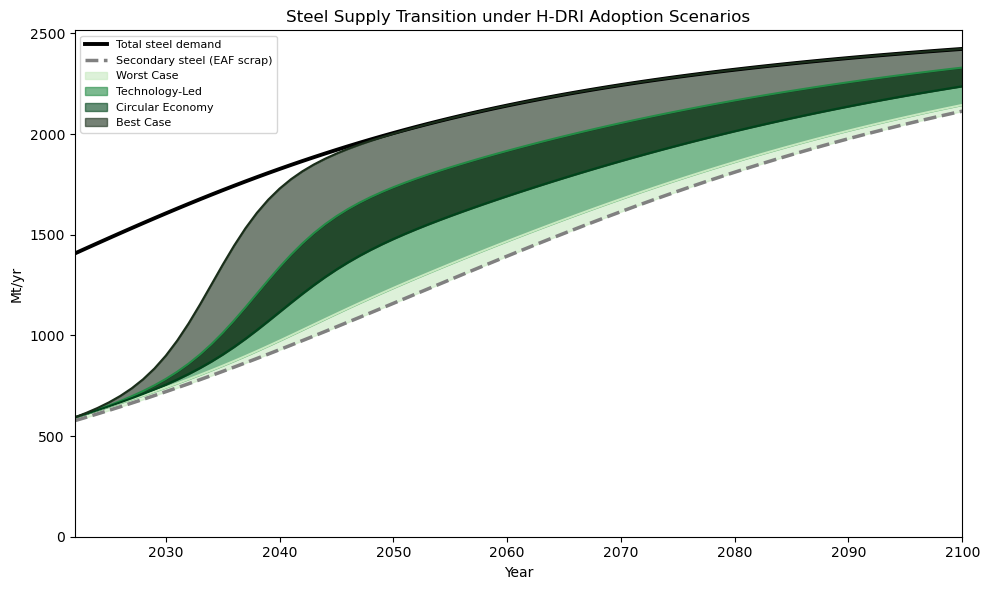

In [10]:
colors_dri = {'Worst Case': '#c7e9c0', 'Technology-Led': '#238b45', 'Circular Economy': '#00441b', 'Best Case': '#1a2e1a'}

fig, ax = plt.subplots(figsize=(10, 6))
eaf = future['scrap_supply'].values / 1e6
ax.plot(plot_years, future['total_inflow'].values / 1e6, color='black', linewidth=2.8, label='Total steel demand')
ax.plot(plot_years, eaf, color='gray', linewidth=2.5, linestyle='--', label='Secondary steel (EAF scrap)')

prev = eaf.copy()
for scenario, color in colors_dri.items():
    dri  = production_results[scenario]['DRI Production'] / 1e6
    curr = eaf + dri
    ax.fill_between(plot_years, prev, curr, color=color, alpha=0.6, label=scenario)
    ax.plot(plot_years, curr, color=color, linewidth=1.5)
    prev = curr

ax.set_title('Steel Supply Transition under H-DRI Adoption Scenarios')
ax.set_xlabel('Year'); ax.set_ylabel('Mt/yr')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0)
plt.tight_layout()
plt.show()

## 6. CO2 emissions — conventional vs green DRI (first scenario)

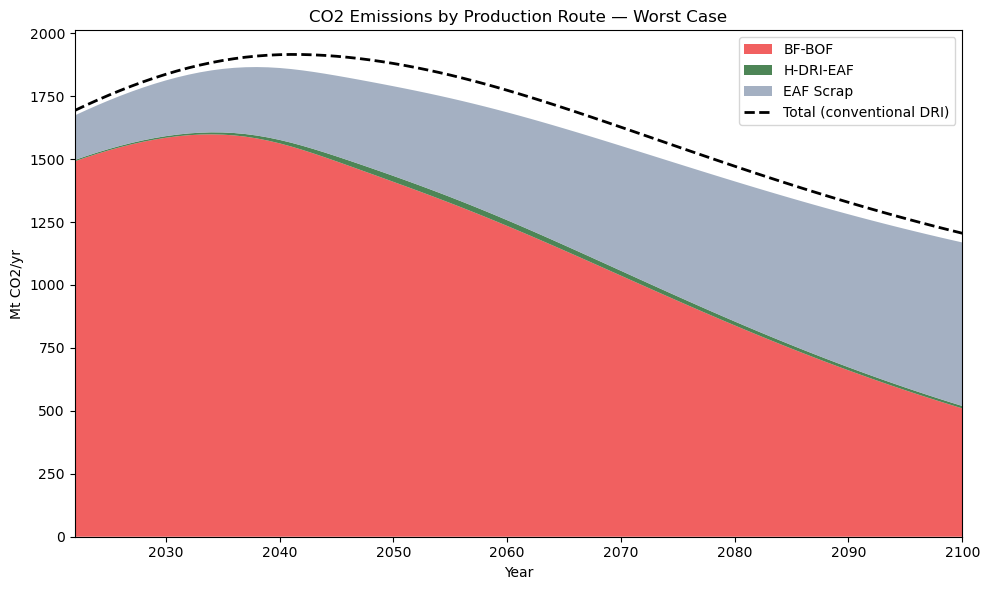

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
scenario = list(scenarios_primary.keys())[0]

bf  = emissions_results[scenario]['BF Emissions']
dri = emissions_results[scenario]['Green DRI Emissions']
eaf = emissions_results[scenario]['EAF Emissions']
dri_conv_total = (emissions_results[scenario]['BF Emissions'] +
                   emissions_results[scenario]['DRI Emissions'] +
                   emissions_results[scenario]['EAF Emissions'])

ax.stackplot(plot_years, bf, dri, eaf,
             labels=['BF-BOF', 'H-DRI-EAF', 'EAF Scrap'],
             colors=['#ef4444', '#2e7038', '#94a3b8'], alpha=0.85)
ax.plot(plot_years, dri_conv_total, color='black', linewidth=2,
        linestyle='--', label='Total (conventional DRI)', zorder=5)
ax.set_title(f'CO2 Emissions by Production Route — {scenario}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2/yr')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper right'); ax.grid(True, alpha=0)
plt.tight_layout()
plt.show()

## 7. CO2 emissions across all scenarios

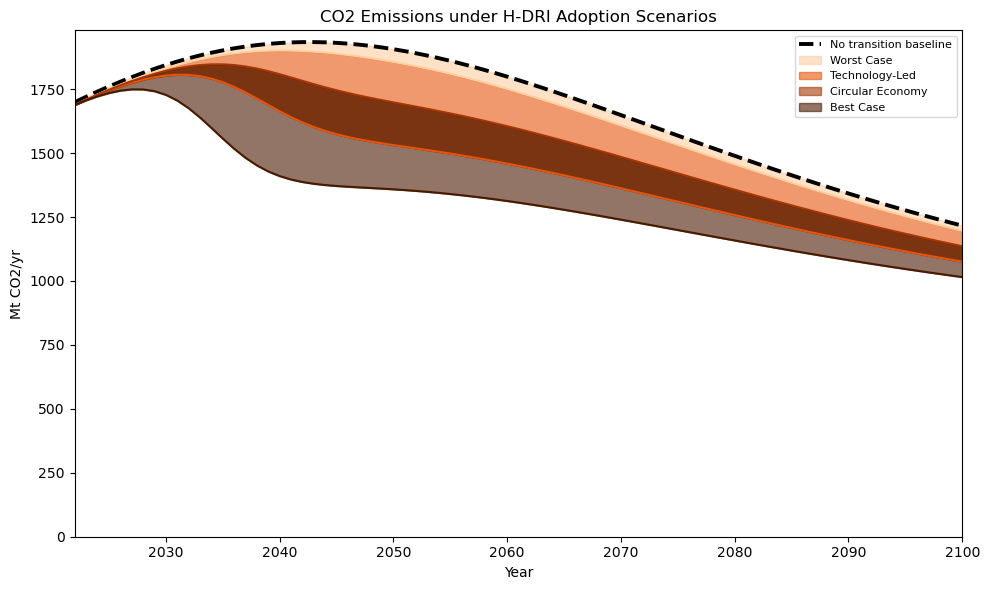

In [14]:
colors_em = {'Worst Case': '#fdd0a2',
             'Technology-Led': '#e6550d', 'Circular Economy': '#a63603', 'Best Case': '#4a1a00'}

fig, ax = plt.subplots(figsize=(10, 6))
eaf_base = future['scrap_supply'].values / 1e6 * emissions_factor_EAF
baseline_em = future['primary_steel_needed'].values / 1e6 * emissions_factor_BF + eaf_base
ax.plot(plot_years, baseline_em, color='black', linewidth=2.8, linestyle='--', label='No transition baseline')

prev = baseline_em.copy()
for scenario, color in colors_em.items():
    curr = emissions_results[scenario]['Total Emissions']
    ax.fill_between(plot_years, curr, prev, color=color, alpha=0.6, label=scenario)
    ax.plot(plot_years, curr, color=color, linewidth=1.5)
    prev = curr

ax.set_title('CO2 Emissions under H-DRI Adoption Scenarios')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2/yr')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0)
plt.tight_layout()
plt.show()

## 8. Green hydrogen demand — first scenario

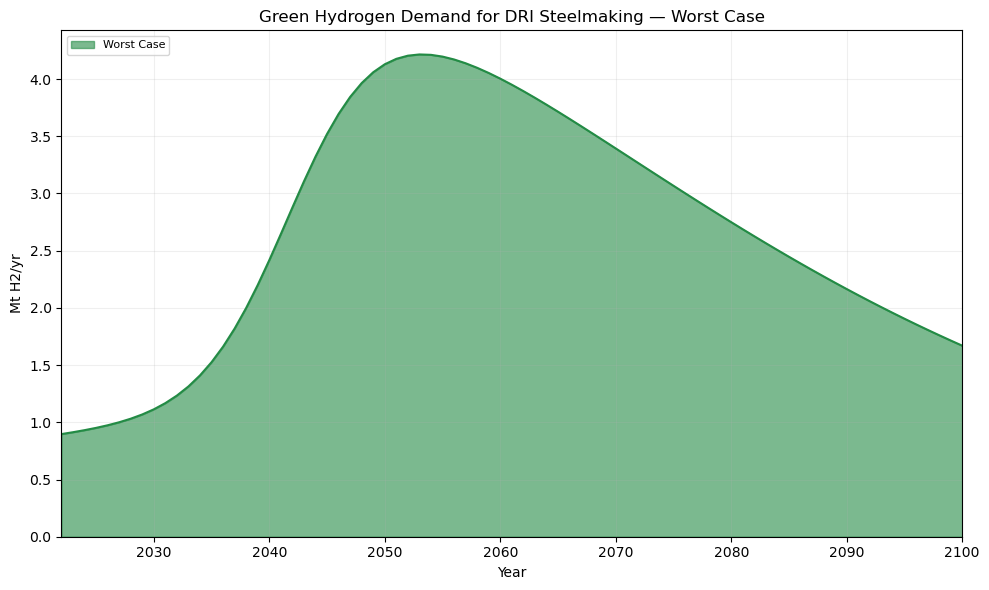

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
scenario = list(scenarios_primary.keys())[0]
h2 = h2_results[scenario]['H2 Demand (Mt)']
ax.fill_between(plot_years, 0, h2, color='#238b45', alpha=0.6, label=scenario)
ax.plot(plot_years, h2, color='#238b45', linewidth=1.5)
ax.set_title(f'Green Hydrogen Demand for DRI Steelmaking — {scenario}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt H2/yr')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Green hydrogen demand — all scenarios

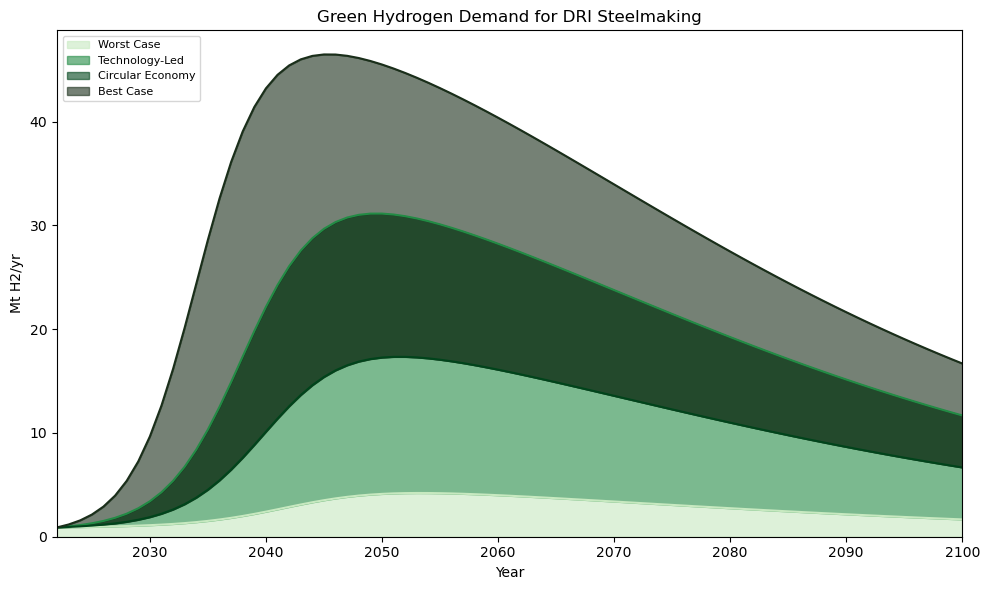

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
prev = np.zeros(len(plot_years))
for scenario, color in colors_dri.items():
    curr = h2_results[scenario]['H2 Demand (Mt)']
    ax.fill_between(plot_years, prev, curr, color=color, alpha=0.6, label=scenario)
    ax.plot(plot_years, curr, color=color, linewidth=1.5)
    prev = curr
ax.set_title('Green Hydrogen Demand for DRI Steelmaking')
ax.set_xlabel('Year'); ax.set_ylabel('Mt H2/yr')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0)
plt.tight_layout()
plt.show()

## 10. Hydrogen demand by electrolyzer type — first scenario

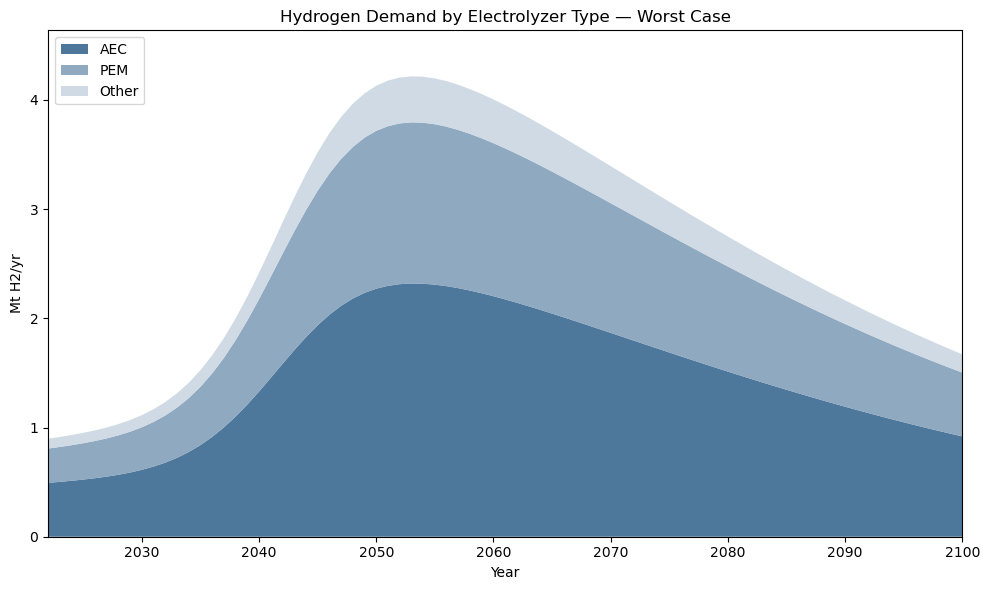

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
scenario = list(scenarios_primary.keys())[0]
aec   = h2_results[scenario]['AEC H2']
pem   = h2_results[scenario]['PEM H2']
other = h2_results[scenario]['Other H2']
ax.stackplot(plot_years, aec, pem, other,
             labels=['AEC', 'PEM', 'Other'],
             colors=['#2e5f8a', '#7a9ab5', '#c8d4e0'], alpha=0.85)
ax.set_title(f'Hydrogen Demand by Electrolyzer Type — {scenario}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt H2/yr')
ax.set_xlim(xlims); ax.set_ylim(0, max(h2_results[scenario]['H2 Demand (Mt)']) * 1.1)
ax.legend(loc='upper left'); ax.grid(True, alpha=0)
plt.tight_layout()
plt.show()

## 11. Electrolyzer capacity + annual additions — first scenario

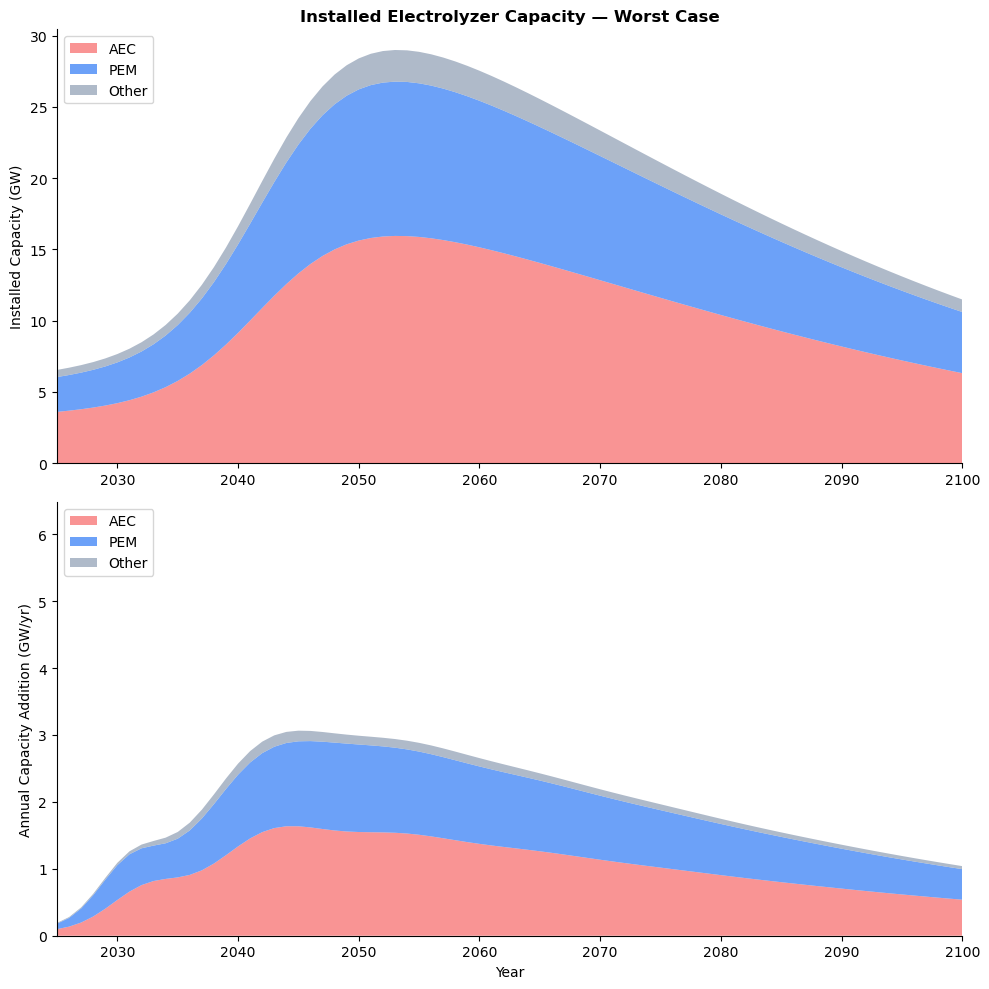

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
scenario = list(scenarios_primary.keys())[0]

cap_aec   = dsm_results[scenario]['cap_AEC']
cap_pem   = dsm_results[scenario]['cap_PEM']
cap_other = dsm_results[scenario]['cap_Other']
i_aec     = dsm_results[scenario]['i_AEC']
i_pem     = dsm_results[scenario]['i_PEM']
i_other   = dsm_results[scenario]['i_Other']

axes[0].stackplot(years, cap_aec, cap_pem, cap_other,
                  labels=['AEC', 'PEM', 'Other'],
                  colors=['#f87171', '#3b82f6', '#94a3b8'], alpha=0.75)
axes[0].set_title(f'Installed Electrolyzer Capacity — {scenario}', fontweight='bold')
axes[0].set_ylabel('Installed Capacity (GW)')
axes[0].set_xlim(years[3], years[-1])
axes[0].legend(loc='upper left')

axes[1].stackplot(years, i_aec, i_pem, i_other,
                  labels=['AEC', 'PEM', 'Other'],
                  colors=['#f87171', '#3b82f6', '#94a3b8'], alpha=0.75)
axes[1].set_ylabel('Annual Capacity Addition (GW/yr)')
axes[1].set_xlabel('Year')
axes[1].set_xlim(years[3], years[-1])
axes[1].legend(loc='upper left')

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(True, alpha=0)

plt.tight_layout()
plt.show()

## 12. Nickel demand

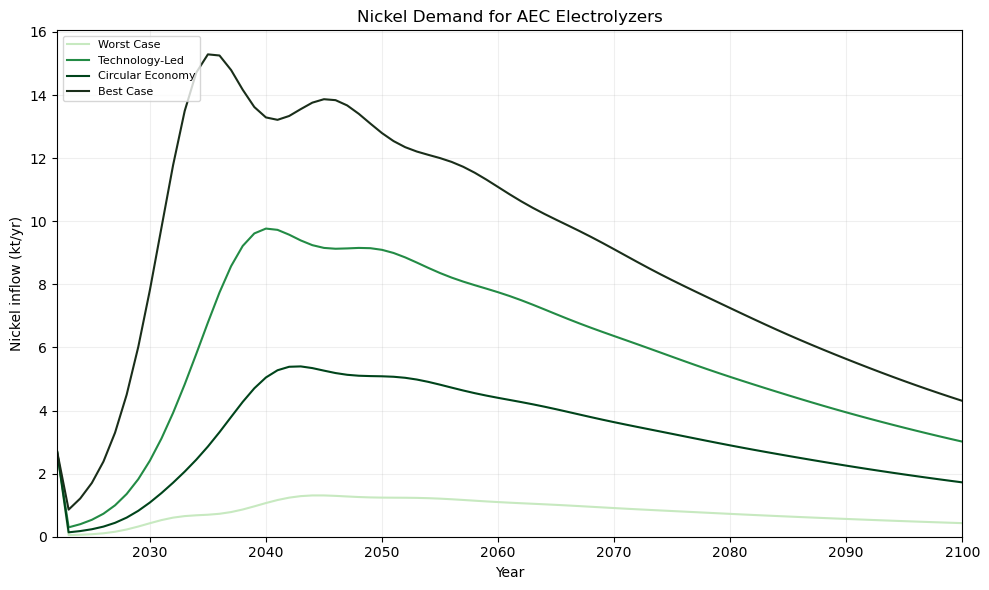

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
for scenario, color in colors_dri.items():
    ax.plot(years, materials[scenario]['nickel_inflow'], color=color, linewidth=1.5, label=scenario)
ax.set_title('Nickel Demand for AEC Electrolyzers')
ax.set_xlabel('Year'); ax.set_ylabel('Nickel inflow (kt/yr)')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Platinum demand

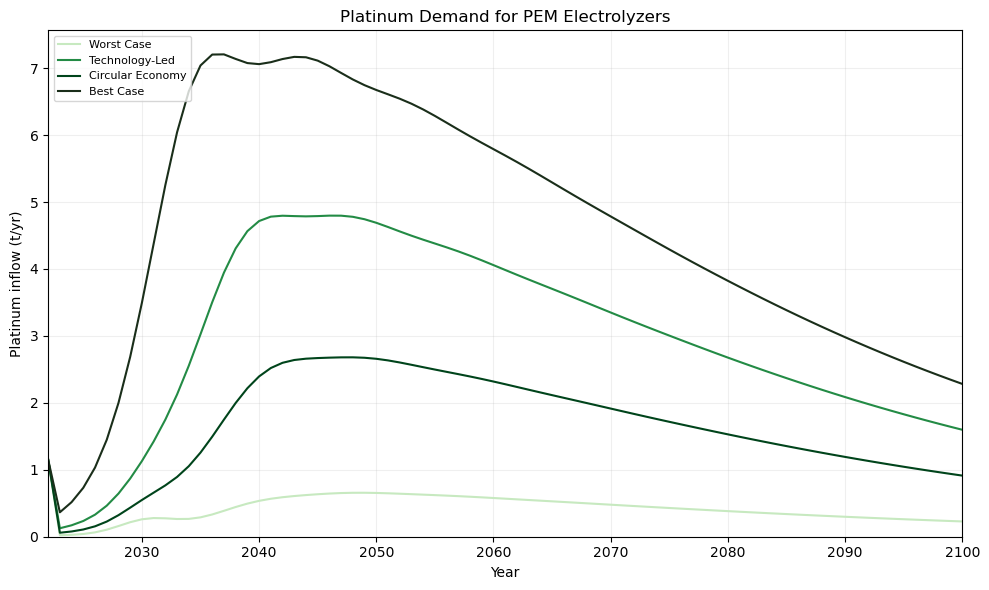

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
for scenario, color in colors_dri.items():
    ax.plot(years, materials[scenario]['platinum_inflow'] * 1000, color=color, linewidth=1.5, label=scenario)
ax.set_title('Platinum Demand for PEM Electrolyzers')
ax.set_xlabel('Year'); ax.set_ylabel('Platinum inflow (t/yr)')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 14. Iridium demand vs available supply

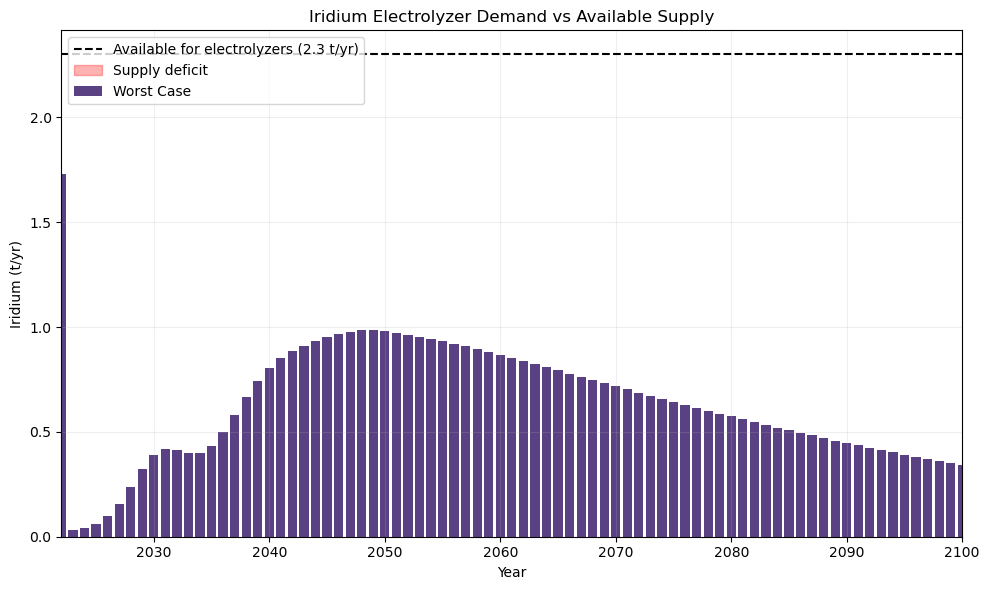

In [23]:
iridium_supply       = 7.3   # t/yr total mineral supply
iridium_other_demand = 5.0   # t/yr other industries
iridium_available    = iridium_supply - iridium_other_demand

fig, ax = plt.subplots(figsize=(10, 6))
scenario = list(scenarios_primary.keys())[0]
ir = materials[scenario]['iridium_inflow'] * 1000  # kt to t

ax.bar(years, ir, color='#3d1f6e', alpha=0.85, label=scenario)
ax.axhline(iridium_available, linestyle='--', color='black', linewidth=1.5,
           label=f'Available for electrolyzers ({iridium_available:.1f} t/yr)')
ax.fill_between(years, iridium_available, ir,
                where=ir > iridium_available, alpha=0.3, color='red', label='Supply deficit')
ax.set_title('Iridium Electrolyzer Demand vs Available Supply')
ax.set_xlabel('Year'); ax.set_ylabel('Iridium (t/yr)')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left'); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 15. PGM demand (Pt + Ir)

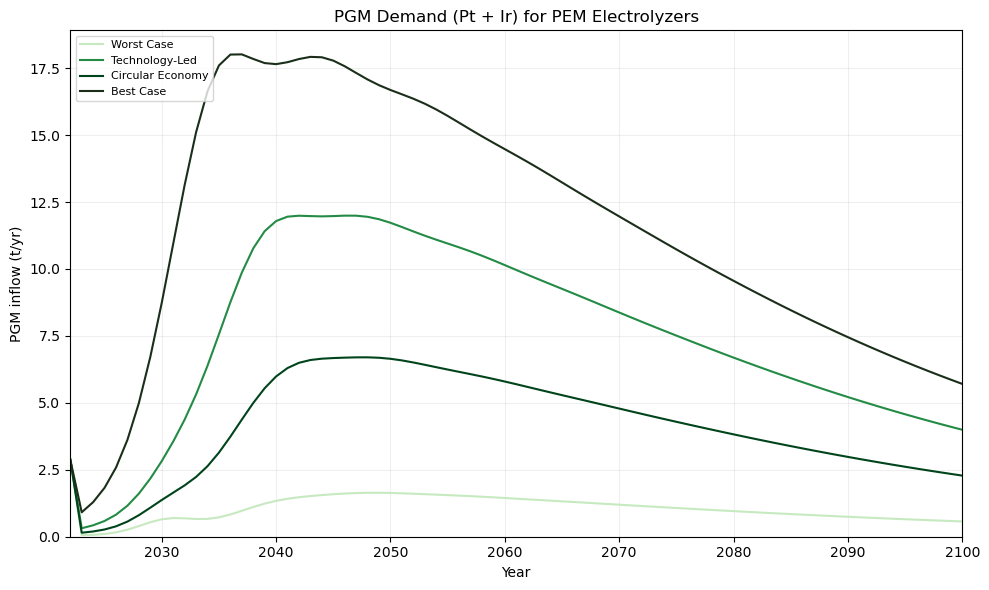

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
for scenario, color in colors_dri.items():
    pgm = (materials[scenario]['platinum_inflow'] + materials[scenario]['iridium_inflow']) * 1000  # t
    ax.plot(years, pgm, color=color, linewidth=1.5, label=scenario)
ax.set_title('PGM Demand (Pt + Ir) for PEM Electrolyzers')
ax.set_xlabel('Year'); ax.set_ylabel('PGM inflow (t/yr)')
ax.set_xlim(xlims); ax.set_ylim(0)
ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()